## Georg Seismic Experiment

Explore seismic signals at Bonn

## Imports

In [1]:
import os
import gc
import matplotlib.pyplot as plt
import numpy as np
import obspy as obs
import pandas as pd

from obspy.signal import PPSD

# from andbro__read_sds import __read_sds

## Configurations

In [2]:
config = {}

config['path_to_inv'] = "/home/andbro/kilauea-data/GEORG/stationxml/"

config['path_to_data'] = "/home/andbro/kilauea-data/GEORG/data/"

config['tbeg'] = obs.UTCDateTime("2024-12-17 02:00")
config['tend'] = obs.UTCDateTime("2024-12-17 04:00")


### Load Data

### Load Seismometer Data

In [3]:
st_seis = obs.read(config['path_to_data']+'BONN_centaur-3_10343_20241216_180000.seed')

inv_seis = obs.read_inventory(config['path_to_inv']+'station_XX_BONN.xml')

print(st_seis)

3 Trace(s) in Stream:
XN.BONN..HHZ | 2024-12-16T18:00:00.000000Z - 2024-12-17T05:59:59.995000Z | 200.0 Hz, 8640000 samples
XN.BONN..HHN | 2024-12-16T18:00:00.000000Z - 2024-12-17T05:59:59.995000Z | 200.0 Hz, 8640000 samples
XN.BONN..HHE | 2024-12-16T18:00:00.000000Z - 2024-12-17T05:59:59.995000Z | 200.0 Hz, 8640000 samples


In [4]:
st_seis.remove_response(inv_seis)

3 Trace(s) in Stream:
XN.BONN..HHZ | 2024-12-16T18:00:00.000000Z - 2024-12-17T05:59:59.995000Z | 200.0 Hz, 8640000 samples
XN.BONN..HHN | 2024-12-16T18:00:00.000000Z - 2024-12-17T05:59:59.995000Z | 200.0 Hz, 8640000 samples
XN.BONN..HHE | 2024-12-16T18:00:00.000000Z - 2024-12-17T05:59:59.995000Z | 200.0 Hz, 8640000 samples

### Load Tiltmeter Data

In [5]:
head = ["time", "north", "east", "X1", "X2", "pressure", "X3", "X4", "X5", "X6"]

tilt = pd.read_csv(config['path_to_data']+"LGMBoxmessung12_16.csv", delimiter=";", names=head)

starttime = obs.UTCDateTime(tilt.time[0])
print(starttime)

mean_dt = tilt.time.diff().mean()
print(mean_dt)

sps = 1/mean_dt
print(sps)

2024-12-16T16:36:15.716615Z
1.0550388852159318
0.947832363349653


In [6]:
# plt.plot(tilt.time.diff())

In [7]:
tilt_n = obs.Trace()
tilt_n.stats.network = "XX"
tilt_n.stats.station = "BONN"
tilt_n.stats.location = ""
tilt_n.stats.channel = "LAN"

tilt_n.stats.starttime = starttime
tilt_n.stats.sampling_rate = sps
# tilt_n.stats.delta = mean_dt

tilt_n.data = np.array(tilt.north)

tilt_e = obs.Trace()
tilt_e.stats.network = "XX"
tilt_e.stats.station = "BONN"
tilt_e.stats.location = ""
tilt_e.stats.channel = "LAE"

tilt_e.stats.starttime = starttime
tilt_e.stats.sampling_rate = sps
# tilt_n.stats.delta = mean_dt

tilt_e.data = np.array(tilt.east)

st_tilt = obs.Stream(traces=[tilt_n, tilt_e])

In [8]:
st_tilt

2 Trace(s) in Stream:
XX.BONN..LAN | 2024-12-16T16:36:15.716615Z - 2024-12-17T08:27:11.164489Z | 0.9 Hz, 54080 samples
XX.BONN..LAE | 2024-12-16T16:36:15.716615Z - 2024-12-17T08:27:11.164489Z | 0.9 Hz, 54080 samples

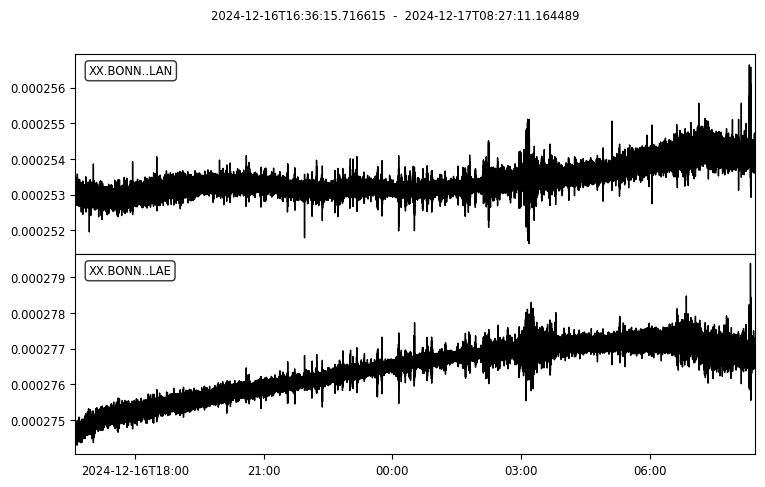

In [9]:
st_tilt.plot();

### Load RaspShake Data

In [10]:
st_rasp = obs.Stream()
st_rasp += obs.read(config['path_to_data']+"AM.RACB0.00.EHZ.D.2024.352")
st_rasp += obs.read(config['path_to_data']+"AM.RACB0.00.EHN.D.2024.352")
st_rasp += obs.read(config['path_to_data']+"AM.RACB0.00.EHE.D.2024.352")

# inv_rasp = obs.read_inventory(config['path_to_inv']+"station_AM_R106A.dataless")
inv_rasp = obs.read_inventory(config['path_to_inv']+"station_AM_RACB0.xml")

for tr in st_rasp:
    # tr.stats.station = "R106A"
    # tr.stats.location = ""
    tr.remove_response(inv_rasp, output="VEL")
    # tr.stats.station = "RACB0"


In [11]:
st_rasp

3 Trace(s) in Stream:
AM.RACB0.00.EHZ | 2024-12-17T00:00:01.216999Z - 2024-12-17T09:23:00.056999Z | 100.0 Hz, 3377885 samples
AM.RACB0.00.EHN | 2024-12-17T00:00:00.886999Z - 2024-12-17T09:24:18.136999Z | 100.0 Hz, 3385726 samples
AM.RACB0.00.EHE | 2024-12-17T00:00:02.086999Z - 2024-12-17T09:22:30.666999Z | 100.0 Hz, 3374859 samples

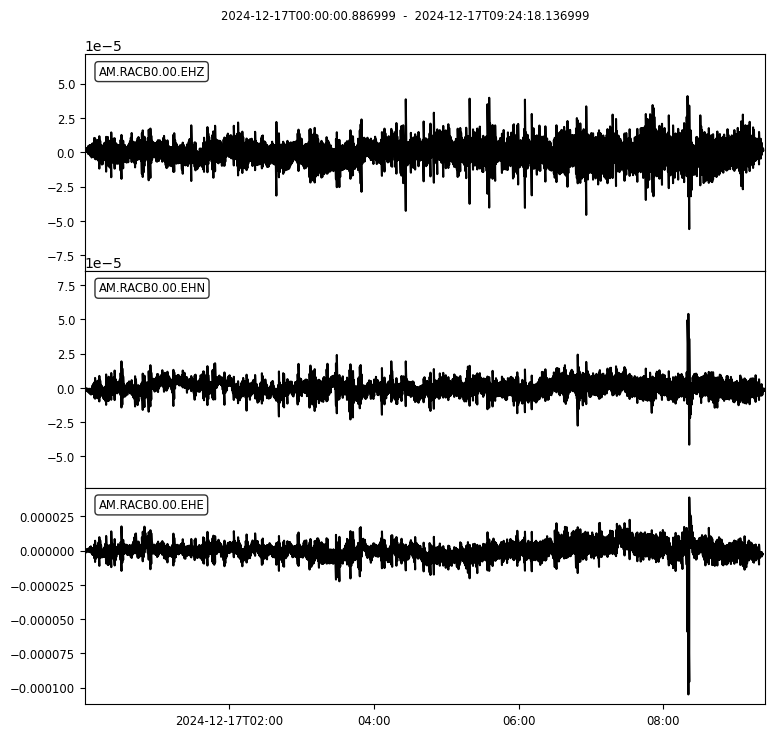

In [12]:
st_rasp.plot();

### Combine Data

In [13]:
st = obs.Stream()
st += st_seis.copy()
st += st_tilt.copy()
st += st_rasp.copy()

In [14]:
st = st.detrend("demean")
st = st.taper(0.05)
st = st.filter("bandpass", freqmin=0.01, freqmax=0.1, corners=4, zerophase=True)

st = st.trim(config['tbeg'], config['tend'])

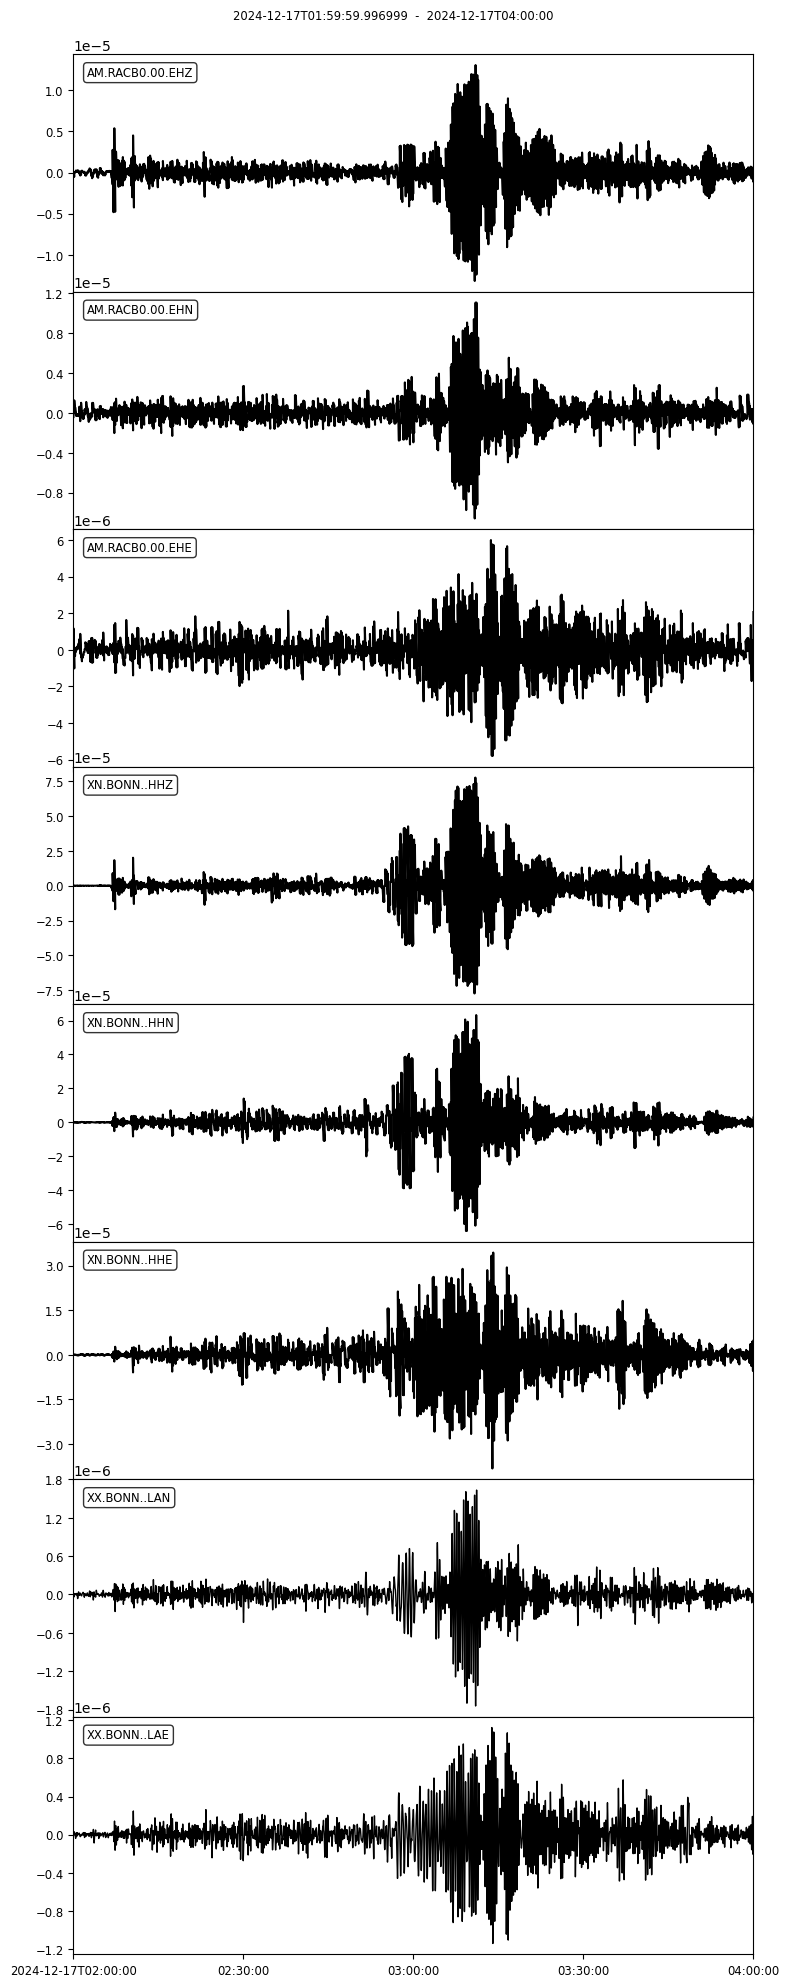

In [15]:
st.plot(equal_scale=False);

In [16]:
%matplotlib tk

In [17]:
stx = st.copy()
stx = stx.trim(config['tbeg']+3100, config['tend']-2200)

In [18]:
shift = stx.select(channel="EHN")[0].data
shift = np.roll(shift, -5)

plt.plot(stx.select(channel="HHN")[0].times(), stx.select(channel="HHN")[0].data/10)
# plt.plot(stx.select(channel="LAN")[0].times(), stx.select(channel="LAN")[0].data)
plt.plot(stx.select(channel="EHN")[0].times(), shift)
plt.show()

In [19]:
st

8 Trace(s) in Stream:
XN.BONN..HHZ    | 2024-12-17T02:00:00.000000Z - 2024-12-17T04:00:00.000000Z | 200.0 Hz, 1440001 samples
XN.BONN..HHN    | 2024-12-17T02:00:00.000000Z - 2024-12-17T04:00:00.000000Z | 200.0 Hz, 1440001 samples
XN.BONN..HHE    | 2024-12-17T02:00:00.000000Z - 2024-12-17T04:00:00.000000Z | 200.0 Hz, 1440001 samples
XX.BONN..LAN    | 2024-12-17T02:00:00.263275Z - 2024-12-17T03:59:59.848628Z | 0.9 Hz, 6825 samples
XX.BONN..LAE    | 2024-12-17T02:00:00.263275Z - 2024-12-17T03:59:59.848628Z | 0.9 Hz, 6825 samples
AM.RACB0.00.EHZ | 2024-12-17T01:59:59.996999Z - 2024-12-17T03:59:59.996999Z | 100.0 Hz, 720001 samples
AM.RACB0.00.EHN | 2024-12-17T01:59:59.996999Z - 2024-12-17T03:59:59.996999Z | 100.0 Hz, 720001 samples
AM.RACB0.00.EHE | 2024-12-17T01:59:59.996999Z - 2024-12-17T03:59:59.996999Z | 100.0 Hz, 720001 samples

In [20]:
config = {}

config['ring'] = "Z"

config['delta'] = 10

# for FSR ex5 (after fixation 2024-10-01 14:00)
config['name'] = "ex0"
config['tbeg'] = UTCDateTime("2024-10-01 00:00")
config['tend'] = UTCDateTime("2024-10-01 04:00")
flim1, flim2 = 315.0, 316.0

# no jumps
# config['name'] = "no_jumps"
# config['tbeg'] = UTCDateTime("2024-09-12 16:00")
# config['tend'] = UTCDateTime("2024-09-14 02:00")
# flim1, flim2 = 553.572, 553.585

# path to Sagnac data
config['path_to_autodata'] = "/import/kilauea-data/sagnac_frequency/bonn/"

config['path_to_data'] = "/import/kilauea-data/sagnac_frequency/bonn/backscatter/"

config['path_to_out_data'] = "/import/kilauea-data/sagnac_frequency/bonn/data/"

config['path_to_figs'] = "/import/kilauea-data/sagnac_frequency/bonn/"


NameError: name 'UTCDateTime' is not defined

### Load backscatter data

In [ ]:
read_pickle("/import/kilauea-data/sagnac_frequency/bonn/FJZ_20241001_00:00:00_backscatter.pkl")

In [ ]:
bs = __load_backscatter_data(config['tbeg'], config['tend']+86400, config['ring'], config['path_to_data'], label="")

In [ ]:
# add time seconds
bs['time_sec'] = bs.time2 - bs.time1 + (bs.time1 - config['tbeg'])

# cut to time period
bs = bs[(bs.time1 > config['tbeg']) & (bs.time2 < config['tend'])]

In [ ]:
bs

In [ ]:
plt.plot(bs.time_sec/3600, bs.fj_fs)
plt.ylabel("Sagnac Frequency / Hz")
plt.xlabel("Time / hours")

In [ ]:
from allantools import oadev, adev

In [ ]:
# define tau range e.g. 5 (= 10⁵) and number of samples N
upper = 6
lower = -4
N = 150

# list of tau values in seconds
taux = np.logspace(lower, upper, N)

# smallest sampling in seconds
dtaux = taux[1]-taux[0]

omegaE = 2*np.pi/86400
scalef = 4/632.8e-9

data = bs.fj_fs.values / scalef / omegaE

taus, ad, ade, ns = oadev(data, rate=1/config['delta'], data_type="freq", taus=taux)


In [ ]:
plt.loglog(taus, ad)
plt.grid(True, which="both")
plt.xlabel("Tau / s")
plt.ylabel("Overlapping Allan Deviation $\Omega$/$\Omega_E$")